In [1]:
# unit test CAS_preprocess_01_unskew_image
import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
from natsort import natsorted
from PIL import Image
from scipy.signal import find_peaks
import cv2 as cv
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import argparse
from datetime import datetime as dt
import h5py
import sys
import ast

%matplotlib inline

# code_dir = Path('/code/')
# sys.path.append(str(code_dir))

# import CAS_preprocess_01_unskew_image_V1 as unskew_image


# SAT_VAL = 12000
# FIBER_WIDTH = 60

## Load image (Smrithi)

In [3]:
paths = {'raw_data': '/data/HSFP_775510_2025-02-20_11-08-27/fib/'}

# Load calibration sequence images and metadata
path = paths['raw_data']
path = str(path)
path = os.path.join(path,'CalibrationFiles')
metadata_file = glob.glob(os.path.join(path,'session_params*.csv'))
print(metadata_file)
metadata = pd.read_csv(metadata_file[0])
files = os.listdir(path)
print(files)
tiff_dir = os.path.join(path,files[1])
tiff_files = os.listdir(tiff_dir)
tiff_files = np.array(natsorted(tiff_files))
print(tiff_files)
tiff_file_path = os.path.join(tiff_dir,tiff_files[0])
tiff = Image.open(tiff_file_path)
image_sequence = []
while True:
    try:
        image_sequence.append(np.array(tiff))
        tiff.seek(tiff.tell() + 1)
    except EOFError:
        break
        
img = np.array(image_sequence)
img2d = img.mean(axis=0)
print(img2d.shape)
width = metadata.Width[0] # Camera pixels in x direction
print(width)
Xoffset = metadata.XOffset[0] # Start of camera pixels in x direction
print(Xoffset)
height = metadata.Height[0] # Camera pixels in y direction
print(height)
Yoffset = metadata.YOffset[0] # Start of camera pixels in y direction
print(Yoffset)
img_to_unskew = np.array(img2d)


['/data/HSFP_775510_2025-02-20_11-08-27/fib/CalibrationFiles/session_params_2025-02-20T10_48_01.csv']
['session_params_2025-02-20T10_48_01.csv', 'Tiffs', 'TTL_2025-02-20T10_48_01.8642944-08_00', 'TTL_TS_2025-02-20T10_48_01.csv']
['Tiffs0.tif' 'Tiffs1.tif' 'Tiffs2.tif' 'Tiffs3.tif' 'Tiffs4.tif'
 'Tiffs5.tif' 'Tiffs6.tif' 'Tiffs7.tif' 'Tiffs8.tif' 'Tiffs9.tif'
 'Tiffs10.tif' 'Tiffs11.tif' 'Tiffs12.tif']
(204, 1488)
1488
348
204
524


## Load image (Carrie)

In [4]:
# Test load_session_paths
Data_dir = '/data/'
Session_id = os.listdir(Data_dir)[0]
Path_1 = os.path.join(Data_dir,Session_id)
Calib_path_1 = os.path.join(Path_1,'fib/CalibrationFiles')

Metadata_file_1 = glob.glob(os.path.join(Calib_path_1,'*.csv'))
Session_params_file_1 = [f for f in Metadata_file_1 if 'session_params' in os.path.basename(f)]
Metadata_1 = pd.read_csv(Session_params_file_1[0])

Tiff_dir_1 = os.path.join(Calib_path_1,'Tiffs')
Tiff_files_1 = os.listdir(Tiff_dir_1)
Tiff_files_1 = np.array(natsorted(Tiff_files_1))
# take the first tiff file and build its full path
Tiff_file_path_1 = os.path.join(Tiff_dir_1,Tiff_files_1[0])
# open the tiff using python imaging library
Tiff_1 = Image.open(Tiff_file_path_1)
Image_sequence_1 = []
# Extract all frames from the first multi-frame tiff into an image_sequence list of numpy arrays (each represents one frame/image)
while True:
    try:
        Image_sequence_1.append(np.array(Tiff_1))
        Tiff_1.seek(Tiff_1.tell() + 1)
    except EOFError:
        break
print('\nnumber of images in tiff: ')
print(len(Image_sequence_1))
Img_1 = np.array(Image_sequence_1) # convert the list of frames into a 3D numpy array (num_frames, height, width)
Img2d_1 = Img_1.mean(axis=0) # average across all frames (axis=0) to create a single 2D image
Img_to_unskew_1 = np.array(Img2d_1)

# extract camera ROI metadata (x and y length + positioning)
Width_1 = Metadata_1.Width[0] # camera pixels in x direction

Xoffset_1 = Metadata_1.XOffset[0] # start of camera pixels in x direction

Height_1 = Metadata_1.Height[0] # camera pixels in y direction

Yoffset_1 = Metadata_1.YOffset[0] # start of camera pixels in y direction


number of images in tiff: 
1000


In [6]:
# Compare
assert path == Calib_path_1, "Calibration paths differ!"

pd.testing.assert_frame_equal(metadata, Metadata_1)
assert np.array_equal(img2d, Img2d_1, equal_nan=True)
print(np.min(img2d), np.max(img2d), np.mean(img2d))
print(np.min(Img2d_1), np.max(Img2d_1), np.mean(Img2d_1))
np.allclose(img2d, Img2d_1)


95.649 13615.512 2160.853824293696
95.649 13615.512 2160.853824293696


True

## Rotate image (Smrithi)

In [7]:
h_line = np.mean(img_to_unskew,axis=0)
h_laser_pix, _ = find_peaks(h_line, height=2000, distance=100)
count = 0
sat_val = 12000 # Threshold for pixels that contain lasers
v_laser_pix = np.zeros(np.size(h_laser_pix))
for l in h_laser_pix:
    v_line = img_to_unskew[:,l]
    v_line[v_line<sat_val] = 0
    idx = np.nonzero(np.diff(v_line))[0]
    v_laser_pix[count] = np.round((idx[0]+idx[-1])/2)
    count +=1

# Angle to rotate
theta_r = np.rad2deg(np.arctan((v_laser_pix[-2]-v_laser_pix[0])/(h_laser_pix[-2]-h_laser_pix[0])))
print(theta_r)

# Rotation using openCV
rows,cols = img_to_unskew.shape
M = cv.getRotationMatrix2D(((cols-1)/2.0,(rows-1)/2.0),theta_r,1)
img_rotated = cv.warpAffine(img_to_unskew,M,(cols,rows))
img_rotated.shape


# Check position of lasers in rotated image
h_line = np.mean(img_rotated,axis=0)
h_laser_pix, _ = find_peaks(h_line, height=2000, distance=100)
count = 0
v_laser_pix = np.zeros(np.size(h_laser_pix))
for l in h_laser_pix:
    v_line = img_rotated[:,l]
    v_line[v_line<sat_val] = 0
    idx = np.nonzero(np.diff(v_line))[0]
    v_laser_pix[count] = np.round((idx[0]+idx[-1])/2)
    count +=1
v_laser_pix = v_laser_pix.astype(int)



-0.9156080256587755


## Rotate image (Carrie)

In [8]:
H_orig_line = np.mean(Img_to_unskew_1,axis=0) # average the image vertically, laser spots will appear as peaks in a horizontal 1D profile
H_orig_laser_pix, _ = find_peaks(H_orig_line, height=2000, distance=100) #find peaks brighter than 2000 and at least 100 pixels apart

# Find laser positions (vertically)
Count = 0 # Initialize counter for laser number
Sat_val = 12000 # Set intensity threshold for pixels that contain lasers
V_orig_laser_pix = np.zeros(np.size(H_orig_laser_pix)) # Initialize array to store vertical positions of each laser

for l in H_orig_laser_pix: # Run the loop for each laser's horizontal position 'l'
    V_orig_line = Img_to_unskew_1[:,l] # Extract a vertical column from the original calibration image at each position 'l'
    V_orig_line[V_orig_line<Sat_val] = 0 # Set all pixels below the sat_val threshold to 0 to isolate the brightest spots
    Idx = np.nonzero(np.diff(V_orig_line))[0] # Find indices where bright spots transition to 0 (top and bottom edges of the laser spot)
    V_orig_laser_pix[Count] = np.round((Idx[0]+Idx[-1])/2) # Find the laser's vertical midpoint by averaging its top and bottom edges
    Count +=1 # Increase the laser counter by 1
    
print(H_orig_laser_pix)
print(V_orig_laser_pix)

# Find the tilt angle between the first and second-to-last laser
Theta_r = np.rad2deg(np.arctan((V_orig_laser_pix[-2]-V_orig_laser_pix[0])/(H_orig_laser_pix[-2]-H_orig_laser_pix[0])))
# v_orig_laser_pix = vertical distance (rise); h_orig_laser_pix = horizontal distance (run); arctan(rise/run) = angle in radians
print('Rotation angle:')
print(Theta_r)

# Rotate image by the calculated angle using openCV
Rows,Cols = Img_to_unskew_1.shape 
M_1 = cv.getRotationMatrix2D(((Cols-1)/2.0,(Rows-1)/2.0),Theta_r,1) # create a rotation transformation matrix
# (cols-1)/2.0,(rows-1)/2.0) = image center; theta_r = tilt angle; 1 = scale (no scaling, just rotation)
Img_rotated = cv.warpAffine(Img_to_unskew_1,M_1,(Cols,Rows)) # apply the rotation transformation to unskew the image

# Confirm that rotation did not alter overall height/width of the image
print('\noriginal image dimensions (height, width):')
print(Img2d_1.shape) 
print('\nunskewed image dimensions (height, width):')
print(Img_rotated.shape) 

H_line = np.mean(Img_rotated,axis=0)
H_laser_pix, _ = find_peaks(H_line, height=2000, distance=100)

# Find laser positions (vertically)
Count = 0
V_laser_pix = np.zeros(np.size(H_laser_pix))
for l in H_laser_pix:
    V_line = Img_rotated[:,l]
    V_line[V_line<Sat_val] = 0
    Idx = np.nonzero(np.diff(V_line))[0]
    V_laser_pix[Count] = np.round((Idx[0]+Idx[-1])/2)
    Count +=1
V_laser_pix = V_laser_pix.astype(int)

[ 432  561  729  870 1277]
[112. 112. 108. 105.  92.]
Rotation angle:
-0.9156080256587755

original image dimensions (height, width):
(204, 1488)

unskewed image dimensions (height, width):
(204, 1488)


In [10]:
# Compare
print(theta_r, Theta_r)  
print(np.allclose(img_rotated, Img_rotated))
print(np.array_equal(img_rotated, Img_rotated))

-0.9156080256587755 -0.9156080256587755
True
True


## Smrithi

In [11]:
use_laser = 1

# Calculate the y-coordinates
v_line = img_rotated[:,h_laser_pix[use_laser]]
v_line[v_line<sat_val] = 0
idx = np.nonzero(np.diff(v_line))[0]
v_width = [idx[0],idx[-1]]

fiber_width = 60

# Calculate the x-coordinates
h_line_top = img_rotated[v_width[0]+5,h_laser_pix[use_laser]-fiber_width:h_laser_pix[use_laser]+fiber_width]
h_line_top[h_line_top<sat_val] = 0
h_line_top_width = np.nonzero(np.diff(h_line_top))[0]
h_top = h_line_top_width[0]


h_line_bot = img_rotated[v_width[1]-5,h_laser_pix[use_laser]-fiber_width:h_laser_pix[use_laser]+fiber_width]
h_line_bot[h_line_bot<sat_val] = 0
h_line_bot_width = np.nonzero(np.diff(h_line_bot))[0]
h_bot = h_line_bot_width[0]

h_width = [h_laser_pix[use_laser]-fiber_width+h_top, h_laser_pix[use_laser]-fiber_width+h_bot]

print(v_width)
print(h_width)

use_laser = 2
# Calculate the y-coordinates
v_line = img_rotated[:,h_laser_pix[use_laser]]
v_line[v_line<sat_val] = 0
idx = np.nonzero(np.diff(v_line))[0]
v_width2 = [idx[0],idx[-1]]

# Calculate the x-coordinates
h_line_top = img_rotated[v_width2[0]+5,h_laser_pix[use_laser]-fiber_width:h_laser_pix[use_laser]+fiber_width]
h_line_top[h_line_top<sat_val] = 0
h_line_top_width = np.nonzero(np.diff(h_line_top))[0]
h_top = h_line_top_width[0]


h_line_bot = img_rotated[v_width2[1]-5,h_laser_pix[use_laser]-fiber_width:h_laser_pix[use_laser]+fiber_width]
h_line_bot[h_line_bot<sat_val] = 0
h_line_bot_width = np.nonzero(np.diff(h_line_bot))[0]
h_bot = h_line_bot_width[0]

h_width2 = [h_laser_pix[use_laser]-fiber_width+h_top, h_laser_pix[use_laser]-fiber_width+h_bot]

print(v_width2)
print(h_width2)

# Affine transformation
pt1 = [h_width[0], v_width[0]]
pt2 = [h_width[1], v_width[1]]
pt3 = [h_width2[0], v_width2[0]]
pt4 = [h_width[1], v_width[0]]
pt5 = [h_width[1], v_width[1]]
pt6 = [h_width2[1], v_width2[0]]
print(pt1, pt2, pt3, pt4, pt5, pt6)

rows,cols = img_rotated.shape
pts1 = np.float32([pt1, pt2, pt3])
pts2 = np.float32([pt4, pt5, pt6])
M = cv.getAffineTransform(pts1,pts2)
img_final = cv.warpAffine(img_rotated,M,(cols,rows))

[47, 170]
[548, 519]
[49, 166]
[719, 689]
[548, 47] [519, 170] [719, 49] [519, 47] [519, 170] [689, 49]


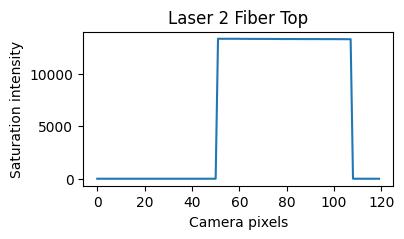

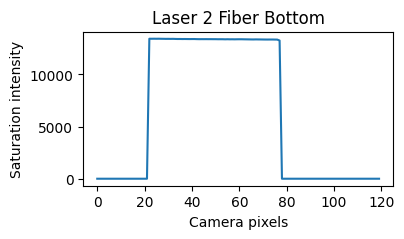

Laser 2
  Vertical pixel indices (top, bottom): [47, 170]
  Horizontal pixel indices (top left, bottom left): [548, 519]




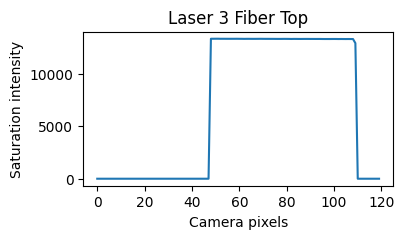

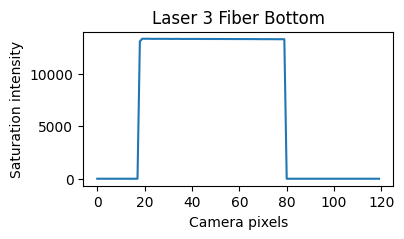

Laser 3
  Vertical pixel indices (top, bottom): [49, 166]
  Horizontal pixel indices (top left, bottom left): [719, 689]


[47, 170] [548, 519] [49, 166] [719, 689]
[548, 47] [519, 170] [719, 49] [519, 47] [519, 170] [689, 49]


In [12]:
def analyze_laser(img_rotated, h_laser_pix, use_laser, sat_val, fiber_width=60):
    """Finds and plots the top/bottom edges of a fiber for a given laser."""
    
    # --- Vertical boundaries ---
    v_line = img_rotated[:, h_laser_pix[use_laser]] # extract one vertical column of pixel intensities at the laser's x-position
    v_line[v_line < sat_val] = 0 # set values below the intensity threshold to zero
    idx = np.nonzero(np.diff(v_line))[0] # find locations where intensity changes (edge of laser)
    v_width = [int(idx[0]), int(idx[-1])] # store the top and bottom y-coordinates of the laser
    
    # --- Horizontal boundaries (top and bottom) ---
    h_width = []
    for position, label, offset in zip(
        [v_width[0] + 5, v_width[1] - 5],
        ["Top", "Bottom"],
        ["h_top", "h_bot"]
    ):
        # Extract horizontal cross-section
        h_line = img_rotated[
            position,
            h_laser_pix[use_laser] - fiber_width : h_laser_pix[use_laser] + fiber_width
        ]
        h_line[h_line < sat_val] = 0
        h_edges = np.nonzero(np.diff(h_line))[0]
        h_edge = int(h_edges[0])

        

        # Convert to absolute coordinates
        h_width.append(int(h_laser_pix[use_laser] - fiber_width + h_edge))

    # --- Print summary ---
    print(f"Laser {use_laser + 1}")
    print(f"  Vertical pixel indices (top, bottom): {v_width}")
    print(f"  Horizontal pixel indices (top left, bottom left): {h_width}\n\n")
    
    return v_width, h_width

def check_laser_post_affine(img, h_laser_pix, use_laser, sat_val, fiber_width=60):
    """ Check the top and bottom of a laser fiber in the post-affine transformed image.
    Parameters
    ----------
    img : 2D array
        The affine-transformed image (img_final)
    h_laser_pix : list or array
        X positions of lasers
    use_laser : int
        Index of the laser to analyze
    fiber_width : int
        Half-width of the horizontal crop around the laser
    sat_val : int
        Threshold value to zero out background pixels
    
    Returns
    -------
    v_width : list of int
        Vertical pixel indices [top, bottom] of the laser
    h_width : list of int
        Horizontal pixel indices [top-left, bottom-left] of the laser
    """
    
    # --- Vertical coordinates ---
    v_line = img[:, h_laser_pix[use_laser]]          # vertical slice at laser x-position
    v_line[v_line < sat_val] = 0                     # threshold low intensity
    idx = np.nonzero(np.diff(v_line))[0]             # edges along y-axis
    v_width = [int(idx[0]), int(idx[-1])]            # top and bottom y-coordinates

    # --- Horizontal coordinates ---
    # Top edge
    h_line_top = img[v_width[0]+5, h_laser_pix[use_laser]-fiber_width:h_laser_pix[use_laser]+fiber_width]
    h_line_top[h_line_top < sat_val] = 0
    # h_top_idx = np.nonzero(np.diff(h_line_top))[0][0]  # first edge
    # h_top = int(h_laser_pix[use_laser] - fiber_width + h_top_idx)
    h_top_idx = np.nonzero(np.diff(h_line_top))[0]
    h_top = int(h_top_idx[0])

    # Bottom edge
    h_line_bot = img[v_width[1]-5, h_laser_pix[use_laser]-fiber_width:h_laser_pix[use_laser]+fiber_width]
    h_line_bot[h_line_bot < sat_val] = 0
    # h_bot_idx = np.nonzero(np.diff(h_line_bot))[0][0]
    # h_bot = int(h_laser_pix[use_laser] - fiber_width + h_bot_idx)
    h_bot_idx = np.nonzero(np.diff(h_line_bot))[0]
    h_bot = int(h_bot_idx[0])

    #h_width = [h_top, h_bot]
    # Convert to absolute coordinates
    h_width = [int(h_laser_pix[use_laser]-fiber_width + h_top),
               int(h_laser_pix[use_laser]-fiber_width + h_bot)]

        
     # --- Print summary ---
    print(f"\nLaser {use_laser + 1}")
    print(f"  Vertical pixel indices (top, bottom): {v_width}")
    print(f"  Horizontal pixel indices (top left, bottom left): {h_width}")

    return v_width, h_width

Use_laser_1 = 1
V_width, H_width = analyze_laser(Img_rotated, H_laser_pix, Use_laser_1, Sat_val, fiber_width=60)

# Find fiber coordinates for laser 3
Use_laser_2 = 2
V_width2, H_width2 = analyze_laser(Img_rotated, H_laser_pix, Use_laser_2, Sat_val, fiber_width=60)

print(V_width, H_width, V_width2, H_width2)


Pt1 = [H_width[0], V_width[0]] # top-left corner of 1st fiber
Pt2 = [H_width[1], V_width[1]] # bottom-left corner of 1st fiber
Pt3 = [H_width2[0], V_width2[0]] # top-left corner of 2nd fiber

# Specify where you want those 3 points to map onto in the transformed image
Pt4 = [H_width[1], V_width[0]] # map top-left of 1st fiber to bottom-left x-position (shear/stretch top in x direction)
Pt5 = [H_width[1], V_width[1]] # map bottom-left of 1st fiber to bottom-left x-position (no transformation)
Pt6 = [H_width2[1], V_width2[0]] # map top-left of 2nd fiber to bottom-left x-position (shear/stretch top in x direction)


print(Pt1, Pt2, Pt3, Pt4, Pt5, Pt6)

Rows,Cols = Img_rotated.shape # get height and width of the image to define the output size in warpAffine
Pts1 = np.float32([Pt1, Pt2, Pt3]) # source points (from original image)
Pts2 = np.float32([Pt4, Pt5, Pt6]) # destination points (where those points should end up in the output image)
M_1 = cv.getAffineTransform(Pts1,Pts2) # compute a 2x3 affine transformation matrix
Img_final = cv.warpAffine(Img_rotated,M_1,(Cols,Rows)) # apply the transformation to the whole image


In [14]:
print(np.allclose(H_laser_pix, h_laser_pix))
print(Sat_val == sat_val)
print(np.allclose(v_width, V_width))
print(np.allclose(h_width, H_width))
print(np.allclose(v_width2, V_width2))
print(np.allclose(h_width2, H_width2))

print(np.allclose(M, M_1))
print(M)
print(M_1)

print(np.allclose(img_final, Img_final))

True
True
True
True
True
True
True
[[ 9.91418140e-01  2.33748992e-01 -3.52833436e+01]
 [-1.13390069e-17  1.00000000e+00  8.15274599e-15]]
[[ 9.91418140e-01  2.33748992e-01 -3.52833436e+01]
 [-1.13390069e-17  1.00000000e+00  8.15274599e-15]]
True


## Check laser

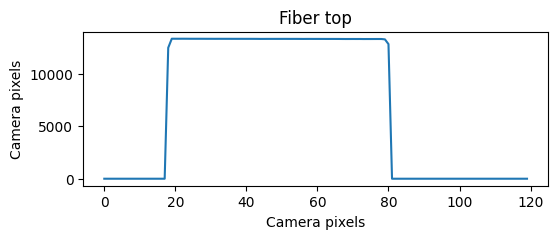

[49, 166]
[69, 89] [126, 146]


In [16]:
use_laser = 2
# Calculate the y-coordinates
v_line = img_final[:,h_laser_pix[use_laser]]
v_line[v_line<sat_val] = 0
idx = np.nonzero(np.diff(v_line))[0]
v_width = [idx[0],idx[-1]]
# Calculate the x-coordinates
h_line_top = img_final[v_width[0]+5,h_laser_pix[use_laser]-fiber_width:h_laser_pix[use_laser]+fiber_width]
h_line_top[h_line_top<sat_val] = 0
h_line_top_width = np.nonzero(np.diff(h_line_top))[0]
h_top = h_line_top_width[0]
f, ax = plt.subplots(figsize=(6,2))
ax.plot(h_line_top)
ax.set(xlabel='Camera pixels', ylabel='Camera pixels', title='Fiber top')
plt.show()
h_line_bot = img_final[v_width[1]-5,h_laser_pix[use_laser]-fiber_width:h_laser_pix[use_laser]+fiber_width]
h_line_bot[h_line_bot<sat_val] = 0
h_line_bot_width = np.nonzero(np.diff(h_line_bot))[0]
h_bot = h_line_bot_width[0]

use_laser = 2
h_line_new = np.mean(img_final,axis=0)
h_laser_pix_new, _ = find_peaks(h_line_new, height=2000, distance=100)
v_line = img_final[:,h_laser_pix_new[use_laser]]
v_line[v_line<sat_val] = 0
idx = np.nonzero(np.diff(v_line))[0]
v_width = [idx[0],idx[-1]]
print(v_width)

fiber1_top = v_width[0]+20
fiber1_bottom = v_width[0]+50-10
fiber2_top = v_width[1]-50+10
fiber2_bottom = v_width[1]-20

fiber1 = [fiber1_top, fiber1_bottom]
fiber2 = [fiber2_top, fiber2_bottom]
print(fiber1, fiber2)

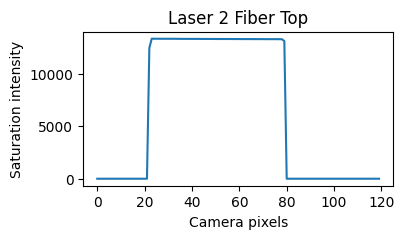

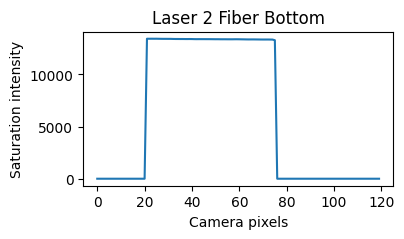


Laser 2
  Vertical pixel indices (top, bottom): [48, 170]
  Horizontal pixel indices (top left, bottom left): [519, 518]


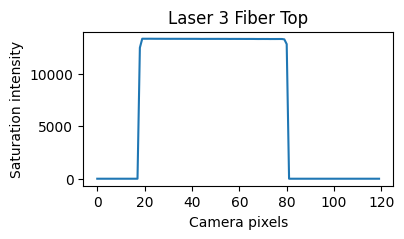

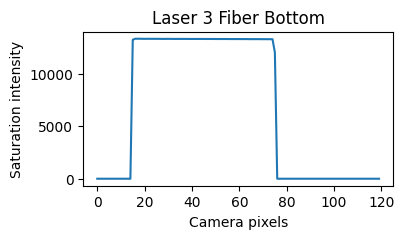


Laser 3
  Vertical pixel indices (top, bottom): [50, 166]
  Horizontal pixel indices (top left, bottom left): [689, 686]
Laser 3 
Vertical pixel indices (top, bottom): [49, 166]


In [17]:
# Check the first laser used
check_laser_post_affine(Img_final, H_laser_pix, Use_laser_1, Sat_val, fiber_width=60)

# Check the second laser used
check_laser_post_affine(Img_final, H_laser_pix, Use_laser_2, Sat_val, fiber_width=60)

# Create a 1D array representing mean brightness at each x-position
H_line_new = np.mean(Img_final,axis=0) # calculate the average intensity along each column of the final image
H_laser_pix_new, _ = find_peaks(H_line_new, height=2000, distance=100) # identify x-positions of peaks above 2000 and at least 100 pixels apart
V_line = Img_final[:,H_laser_pix_new[Use_laser_2]]
V_line[V_line < Sat_val] = 0
Idx = np.nonzero(np.diff(V_line))[0]
V_width = [int(Idx[0]), int(Idx[-1])]
print(f"Laser {Use_laser_2+1} \nVertical pixel indices (top, bottom): {V_width}")

# Adjust the top and bottom of each fiber slightly to define subregions inside the fiber
# Define vertical bounds of the first fiber
Fiber1_top = V_width[0] + 20 # 20 pixels below the top edge
Fiber1_bottom = V_width[0] + 50 - 10 # 40 pixels below the top edge
# Define vertical bounds of the second fiber
Fiber2_top = V_width[1] - 50 + 10 # 40 pixels above the bottom edge
Fiber2_bottom = V_width[1] - 20 # 20 pixels above the bottom edge

# Store the vertical boundaries of each fiber
Fiber1 = [Fiber1_top, Fiber1_bottom]
Fiber2 = [Fiber2_top, Fiber2_bottom]

In [18]:
print(np.allclose(img_final, Img_final))

False


In [8]:
print(np.array_equal(img2d, img_to_unskew, equal_nan=True))
print(np.array_equal(img2d_1, img_to_unskew_1, equal_nan=True))

False
False


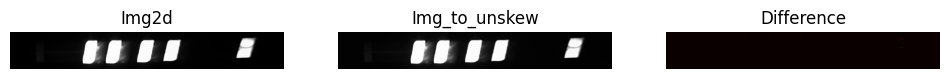

456
11709.914


In [9]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img2d, cmap='gray')
plt.title('Img2d')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_to_unskew, cmap='gray')
plt.title('Img_to_unskew')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(np.abs(img2d - img_to_unskew), cmap='hot')
plt.title('Difference')
plt.axis('off')

plt.show()

diff = img2d - img_to_unskew
num_diff_pixels = np.count_nonzero(diff)
print(num_diff_pixels)
max_diff = np.max(np.abs(img2d - img_to_unskew))
print(max_diff)

In [10]:
# # Test image rotation
# # New .py version
# img_rotated, theta_r = unskew_image.rotate_image(img_to_unskew, h_peaks, v_peaks)

# # Original .ipynb version
# theta_r_1 = np.rad2deg(np.arctan((v_orig_laser_pix_1[-2]-v_orig_laser_pix_1[0])/(h_orig_laser_pix_1[-2]-h_orig_laser_pix_1[0])))
# # Rotate image by the calculated angle using openCV
# rows,cols = img_to_unskew_1.shape 
# M = cv.getRotationMatrix2D(((cols-1)/2.0,(rows-1)/2.0),theta_r_1,1) # create a rotation transformation matrix
# img_rotated_1 = cv.warpAffine(img_to_unskew_1,M,(cols,rows)) # apply the rotation transformation to unskew the image

# print(theta_r)
# print(theta_r_1)

# assert np.array_equal(img_rotated, img_rotated_1), "rotated images differ"
# assert theta_r == theta_r_1, "rotation angles differ"
# assert np.array_equal(img_to_unskew, img_to_unskew_1), "images to unskew differ"

In [11]:
# Test image rotation
# New .py version
img_rotated, theta_r = unskew_image.rotate_image(img_to_unskew, h_peaks, v_peaks)

# Original .ipynb version
theta_r_1 = np.rad2deg(np.arctan((v_orig_laser_pix_1[-2]-v_orig_laser_pix_1[0])/(h_orig_laser_pix_1[-2]-h_orig_laser_pix_1[0])))
# Rotate image by the calculated angle using openCV
rows,cols = img2d_1.shape 
M = cv.getRotationMatrix2D(((cols-1)/2.0,(rows-1)/2.0),theta_r_1,1) # create a rotation transformation matrix
img_rotated_1 = cv.warpAffine(img_to_unskew_1,M,(cols,rows)) # apply the rotation transformation to unskew the image

print(theta_r)
print(theta_r_1)

assert np.array_equal(img_rotated, img_rotated_1), "rotated images differ"
assert theta_r == theta_r_1, "rotation angles differ"
assert np.array_equal(img_to_unskew, img_to_unskew_1), "images to unskew differ"

-0.9156080256587755
-0.9156080256587755


In [12]:
print(h_peaks)
print(v_peaks)


[ 432  561  729  870 1277]
[112 112 108 105  92]


In [13]:
# Test analyze_laser
img_rotated_copy = img_rotated.copy()

# Alt .py version

h_line = np.mean(img_rotated, axis=0)
h_peaks_rot, _ = find_peaks(h_line, height=2000, distance=100)
v_width1, h_width1 = unskew_image.analyze_laser(img_rotated, h_peaks_rot, use_laser=1)
v_width2, h_width2 = unskew_image.analyze_laser(img_rotated, h_peaks_rot, use_laser=2)
print(v_width1, h_width1, v_width2, h_width2)

# Original .ipynb version
h_line_1 = np.mean(img_rotated_1,axis=0)
h_laser_pix, _ = find_peaks(h_line_1, height=2000, distance=100)
def analyze_laser(img_rotated, h_laser_pix, use_laser, sat_val, fiber_width=60):
    """Finds and plots the top/bottom edges of a fiber for a given laser."""
    
    # --- Vertical boundaries ---
    v_line = img_rotated[:, h_laser_pix[use_laser]] # extract one vertical column of pixel intensities at the laser's x-position
    v_line[v_line < sat_val] = 0 # set values below the intensity threshold to zero
    idx = np.nonzero(np.diff(v_line))[0] # find locations where intensity changes (edge of laser)
    v_width = [int(idx[0]), int(idx[-1])] # store the top and bottom y-coordinates of the laser
    
    # --- Horizontal boundaries (top and bottom) ---
    h_width = []
    for position, label, offset in zip(
        [v_width[0] + 5, v_width[1] - 5],
        ["Top", "Bottom"],
        ["h_top", "h_bot"]
    ):
        # Extract horizontal cross-section
        h_line = img_rotated[
            position,
            h_laser_pix[use_laser] - fiber_width : h_laser_pix[use_laser] + fiber_width
        ]
        h_line[h_line < sat_val] = 0
        h_edges = np.nonzero(np.diff(h_line))[0]
        h_edge = int(h_edges[0])

       #  # --- Plot for visualization --- 
       #  f, ax = plt.subplots(figsize=(4, 2))
       #  ax.plot(h_line)
       #  ax.set(
       #      xlabel="Camera pixels",
       #      ylabel="Saturation intensity",
       #      title=f"Laser {use_laser + 1} Fiber {label}"
       #  )
       #  plt.show()

        # Convert to absolute coordinates
        h_width.append(int(h_laser_pix[use_laser] - fiber_width + h_edge))

    # --- Print summary ---
    print(f"Laser {use_laser + 1}")
    print(f"  Vertical pixel indices (top, bottom): {v_width}")
    print(f"  Horizontal pixel indices (top left, bottom left): {h_width}\n\n")
    
    return v_width, h_width

# Find fiber coordinates for laser 2
use_laser_1 = 1
v_width1_orig, h_width1_orig = analyze_laser(img_rotated_1, h_laser_pix, use_laser_1, sat_val, fiber_width=60)

# Find fiber coordinates for laser 3
use_laser_2 = 2
v_width2_orig, h_width2_orig = analyze_laser(img_rotated_1, h_laser_pix, use_laser_2, sat_val, fiber_width=60)
print(v_width1_orig, h_width1_orig, v_width2_orig, h_width2_orig)

assert v_width1 == v_width1_orig
assert h_width1 == h_width1_orig
assert v_width2 == v_width2_orig
assert h_width2 == h_width2_orig
assert np.array_equal(img_rotated, img_rotated_1), "img_rotated changes after going through analyze_laser function" 

[47, 170] [548, 519] [49, 166] [719, 689]
Laser 2
  Vertical pixel indices (top, bottom): [47, 170]
  Horizontal pixel indices (top left, bottom left): [548, 519]


Laser 3
  Vertical pixel indices (top, bottom): [49, 166]
  Horizontal pixel indices (top left, bottom left): [719, 689]


[47, 170] [548, 519] [49, 166] [719, 689]


In [14]:
# Define affine points
pt1, pt2, pt3 = [h_width1[0], v_width1[0]], [h_width1[1], v_width1[1]], [h_width2[0], v_width2[0]]
pt4, pt5, pt6 = [h_width1[1], v_width1[0]], [h_width1[1], v_width1[1]], [h_width2[1], v_width2[0]]

print(pt1, pt2, pt3, pt4, pt5, pt6)

[548, 47] [519, 170] [719, 49] [519, 47] [519, 170] [689, 49]


In [15]:
# Test perform_affine_transform
# New .py version
img_final = unskew_image.perform_affine_transform(img_rotated, [pt1, pt2, pt3], [pt4, pt5, pt6])

# Original .ipynb version
rows,cols = img_rotated_1.shape # get height and width of the image to define the output size in warpAffine
pts1 = np.float32([pt1, pt2, pt3]) # source points (from original image)
pts2 = np.float32([pt4, pt5, pt6]) # destination points (where those points should end up in the output image)
M = cv.getAffineTransform(pts1,pts2) # compute a 2x3 affine transformation matrix
img_final_1 = cv.warpAffine(img_rotated_1,M,(cols,rows)) # apply the transfomration to the whole image

assert np.array_equal(img_final, img_final_1)

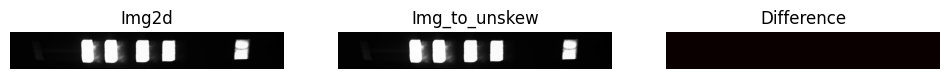

0
0.0


In [16]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img_final, cmap='gray')
plt.title('Img2d')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_final_1, cmap='gray')
plt.title('Img_to_unskew')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(np.abs(img_final - img_final_1), cmap='hot')
plt.title('Difference')
plt.axis('off')

plt.show()

diff = img_final - img_final_1
num_diff_pixels = np.count_nonzero(diff)
print(num_diff_pixels)
max_diff = np.max(np.abs(img_final - img_final_1))
print(max_diff)

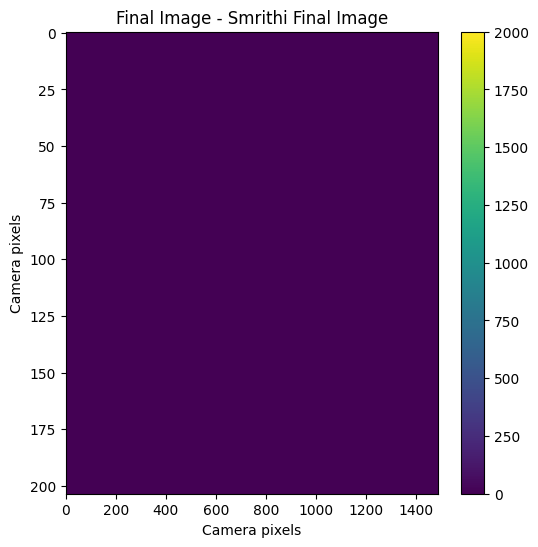

In [17]:
f,ax = plt.subplots(figsize=(6,6))
i = ax.imshow(np.abs(img_final - img_final_1),  aspect='auto', vmin=0, vmax=2000)
ax.set(xlabel='Camera pixels', ylabel='Camera pixels', title='Final Image - Smrithi Final Image')
ax.grid(False)
f.colorbar(i,ax=ax)
plt.show()

In [18]:
# Store fiber boundaries
# New .py version
h_line_final = np.mean(img_final, axis=0)
h_peaks_final, _ = find_peaks(h_line_final, height=2000, distance=100)
fiber1, fiber2 = unskew_image.store_fiber_boundaries(img_final, h_peaks_final, use_laser=2)


# Original .ipynb version
# Create a 1D array representing mean brightness at each x-position
h_line_new = np.mean(img_final_1,axis=0) # calculate the average intensity along each column of the final image
h_laser_pix_new, _ = find_peaks(h_line_new, height=2000, distance=100) # identify x-positions of peaks above 2000 and at least 100 pixels apart
v_line = img_final_1[:,h_laser_pix_new[use_laser_2]]
v_line[v_line < sat_val] = 0
idx = np.nonzero(np.diff(v_line))[0]
v_width_orig = [int(idx[0]), int(idx[-1])]
fiber1_top = v_width_orig[0] + 20 # 20 pixels below the top edge
fiber1_bottom = v_width_orig[0] + 50 - 10 # 40 pixels below the top edge
# Define vertical bounds of the second fiber
fiber2_top = v_width_orig[1] - 50 + 10 # 40 pixels above the bottom edge
fiber2_bottom = v_width_orig[1] - 20 # 20 pixels above the bottom edge

fiber1_orig = [fiber1_top, fiber1_bottom]
fiber2_orig = [fiber2_top, fiber2_bottom]

assert fiber1 == fiber1_orig
assert fiber2 == fiber2_orig

In [19]:
print(fiber1, fiber2)
print(fiber1_orig, fiber2_orig)

[69, 89] [126, 146]
[69, 89] [126, 146]


In [20]:
assert np.array_equal(img_final, img_final_1)

In [21]:
print(Xoffset)
print(Yoffset)

348
524


In [22]:
# Save the affine transformed points and fiber locations
pt1[0] = int(pt1[0] + Xoffset)
pt2[0] = int(pt2[0] + Xoffset)
pt3[0] = int(pt3[0] + Xoffset)
pt4[0] = int(pt4[0] + Xoffset)
pt5[0] = int(pt5[0] + Xoffset)
pt6[0] = int(pt6[0] + Xoffset)
pt1[1] = int(pt1[1] + Yoffset)
pt2[1] = int(pt2[1] + Yoffset)
pt3[1] = int(pt3[1] + Yoffset)
pt4[1] = int(pt4[1] + Yoffset)
pt5[1] = int(pt5[1] + Yoffset)
pt6[1] = int(pt6[1] + Yoffset)

fiber1[0] = int(fiber1[0] + Yoffset)
fiber1[1] = int(fiber1[1] + Yoffset)
fiber2[0] = int(fiber2[0] + Yoffset)
fiber2[1] = int(fiber2[1] + Yoffset)

# Save transformed image for wavelength calibration
img_final_1 = img_final_1.astype(int)
results_dir = Path('/results/')
results_dir.mkdir(parents=True, exist_ok=True)  # ensure folder exists

output_file = results_dir / "CalibrationImage_ipynb.tiff"
cv.imwrite(str(output_file), img_final_1)

with open(results_dir / 'calibration_ipynb.txt','w') as f:
    f.write(f'rot_tform_thetaR = {theta_r_1}\n')
    f.write(f'aff_tform_pt1 = {pt1}\n')
    f.write(f'aff_tform_pt2 = {pt2}\n')
    f.write(f'aff_tform_pt3 = {pt3}\n')
    f.write(f'aff_tform_pt4 = {pt4}\n')
    f.write(f'aff_tform_pt5 = {pt5}\n')
    f.write(f'aff_tform_pt6 = {pt6}\n')
    f.write(f'fiber1_pixels = {fiber1}\n')
    f.write(f'fiber2_pixels = {fiber2}\n')
    f.write(f'calib_Xoffset = {Xoffset}\n')

In [23]:
# Save results
img_final = img_final.astype(int)
results_dir = Path('/results/')
unskew_image.save_results(img_final, theta_r, [pt1, pt2, pt3, pt4, pt5, pt6], [fiber1, fiber2], Xoffset, Yoffset, results_dir)



In [24]:
assert np.array_equal(img_final, img_final_1)

In [25]:
results_dir = Path('/results/')
print(f"Results saved to {results_dir}")
print(f"  - CalibrationImage.tiff")
print(f"  - calibration.txt")

Results saved to /results
  - CalibrationImage.tiff
  - calibration.txt


In [54]:
calib_image = "/data/HSFP_775510_2025-02-20_11-08-27/fib/CalibrationImage.tiff"
#calib_image = "/results/CalibrationImage_ipynb.tiff"
new_image = "/results/CalibrationImage.tiff"


In [55]:
from skimage import io
img_orig = io.imread(calib_image)
img_new = io.imread(new_image)

# Check shape first
if img_orig.shape != img_new.shape:
    print("Images have different shapes:", img_orig.shape, img_new.shape)
else:
    # Check pixel-by-pixel equality
    identical = np.array_equal(img_orig, img_new)
    print("Images are identical:", identical)

    # If not identical, quantify the differences
    if not identical:
        diff = np.abs(img_orig.astype(float) - img_new.astype(float))
        print("Max pixel difference:", np.max(diff))
        print("Mean pixel difference:", np.mean(diff))

Images are identical: False
Max pixel difference: 11517.0
Mean pixel difference: 1.664021320893949


In [56]:
from skimage.metrics import structural_similarity as ssim

ssim_value = ssim(img_orig, img_new, data_range=img_new.max() - img_new.min())
print("SSIM:", ssim_value)

SSIM: 0.9984537559137925


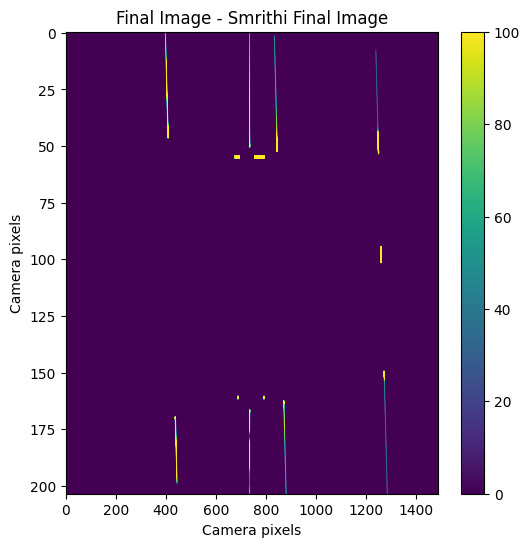

In [57]:
f,ax = plt.subplots(figsize=(6,6))
i = ax.imshow(np.abs(img_new - img_orig),  aspect='auto', vmin=0, vmax=100)
ax.set(xlabel='Camera pixels', ylabel='Camera pixels', title='Final Image - Smrithi Final Image')
ax.grid(False)
f.colorbar(i,ax=ax)
plt.show()